# NetworkX — Order & Payment Graph

This notebook models a simple order-payment knowledge graph.  
Alice places an order for an item; the payment is in **pending** state.  
We then query the graph to check whether Alice has completed payment.

In [4]:
import networkx as nx

# Build the knowledge graph
G = nx.DiGraph()

# Nodes with attributes
G.add_node("Alice",    type="Customer")
G.add_node("Order#101", type="Order",   status="placed")
G.add_node("Laptop",   type="Item",     price=1200)
G.add_node("Payment#1", type="Payment", status="pending")

# Edges (relationships)
G.add_edge("Alice",     "Order#101",   relation="placed_order")
G.add_edge("Order#101", "Laptop",      relation="contains_item")
G.add_edge("Order#101", "Payment#1",   relation="has_payment")

print("=== Graph Overview ===")
print("Nodes:")
for node, attrs in G.nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges:")
for src, tgt, data in G.edges(data=True):
    print(f"  {src} -[{data['relation']}]-> {tgt}")

=== Graph Overview ===
Nodes:
  Alice: {'type': 'Customer'}
  Order#101: {'type': 'Order', 'status': 'placed'}
  Laptop: {'type': 'Item', 'price': 1200}
  Payment#1: {'type': 'Payment', 'status': 'pending'}

Edges:
  Alice -[placed_order]-> Order#101
  Order#101 -[contains_item]-> Laptop
  Order#101 -[has_payment]-> Payment#1


In [5]:
# Check whether Alice has completed payment
def check_payment_status(graph, customer):
    payment_status = None

    # Walk: Customer -> Order -> Payment
    for order in graph.successors(customer):
        edge = graph[customer][order]
        if edge.get("relation") == "placed_order":
            for node in graph.successors(order):
                edge2 = graph[order][node]
                if edge2.get("relation") == "has_payment":
                    payment_status = graph.nodes[node].get("status")
                    payment_node = node

    if payment_status is None:
        print(f"No payment record found for {customer}.")
    elif payment_status == "completed":
        print(f"✔  {customer} has completed payment ({payment_node}).")
    else:
        print(f"✘  {customer} has NOT completed payment — {payment_node} is '{payment_status}'.")

check_payment_status(G, "Alice")

✘  Alice has NOT completed payment — Payment#1 is 'pending'.


C:\Users\veguntur\AppData\Local\Temp\ipykernel_28620\611643752.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


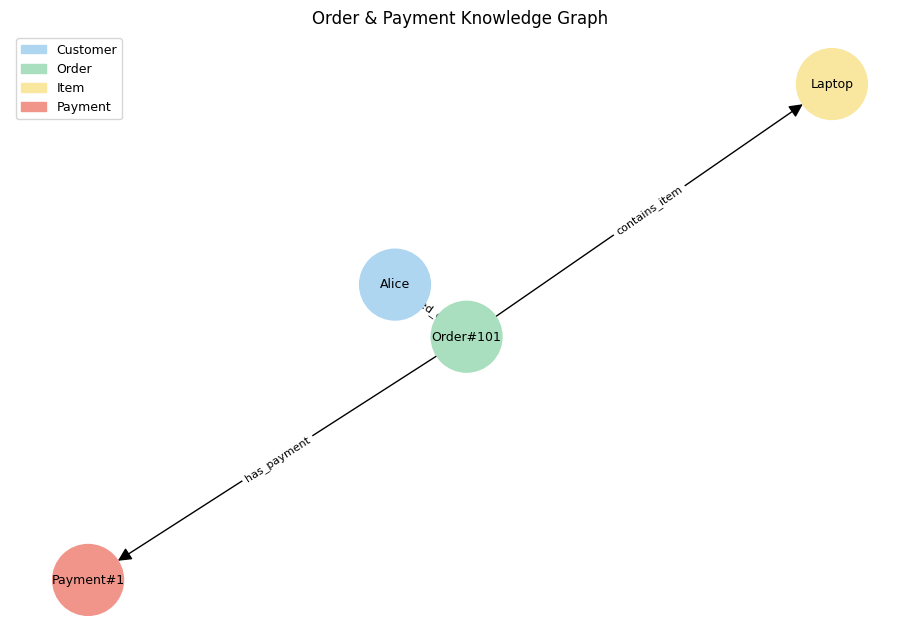

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Color nodes by type
type_colors = {
    "Customer": "#AED6F1",
    "Order":    "#A9DFBF",
    "Item":     "#F9E79F",
    "Payment":  "#F1948A",
}
node_colors = [type_colors[G.nodes[n]["type"]] for n in G.nodes()]

pos = nx.spring_layout(G, seed=7)
edge_labels = {(s, t): d["relation"] for s, t, d in G.edges(data=True)}

plt.figure(figsize=(9, 6))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2600,
    font_size=9,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

# Legend
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
plt.legend(handles=legend_patches, loc="upper left", fontsize=9)

plt.title("Order & Payment Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
load_dotenv(env_path)  # Load environment variables from workspace root .env file

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)